# Test grafico di `metricTTC`
- $V_0 < 0$: collision
- $V_0 > 0$: no collision
- $V_0 = 0$: contact
- $V_0 = 2T$: no collision within time horizon

In [1]:
from pathlib import Path
import sys

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

# Permette di eseguire il notebook sia dalla radice del progetto sia da tests/.
project_root = Path.cwd()
if not (project_root / "hj_reachability").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from hj_reachability import Grid, sets
from hj_reachability.systems.relative_vehicle_6d import RelativeVehicle6D
from hj_reachability.vehicle.geometry import build_terminal_set_boundary
from hj_reachability.vehicle.metrics import metricTTC

## 1. 6D grid

$$z = [x_{rel}, y_{rel}, \theta_{rel}, v_H, \delta_E, v_E].$$

In [2]:
grid = Grid.from_lattice_parameters_and_boundary_conditions(
    domain=sets.Box(
        lo=jnp.array([-8.0, -6.0, -0.5 * np.pi, 0.0, -0.10, 0.0]),
        hi=jnp.array([ 8.0,  6.0,  0.5 * np.pi, 20.0, 0.10, 20.0]),
    ),
    shape=(41, 31, 10, 3, 3, 3),
    periodic_dims=2,
)

print("Ordine dello stato: [x_rel, y_rel, theta_rel, v_H, delta_E, v_E]")
print("Forma della griglia:", grid.shape)
print("Numero totale di stati:", int(np.prod(grid.shape)))

Ordine dello stato: [x_rel, y_rel, theta_rel, v_H, delta_E, v_E]
Forma della griglia: (41, 31, 10, 3, 3, 3)
Numero totale di stati: 343170


## 2. Metric evaluation

In [16]:
boundary = build_terminal_set_boundary(
    n_theta=90,
    n_phi=180,
)

dynamics = RelativeVehicle6D(
    lf=1.2,
    lr=1.5,
)

horizon = 3.0
dt = 0.05

result = metricTTC(
    grid=grid,
    dynamics=dynamics,
    horizon=horizon,
    dt=dt,
)

V0 = np.asarray(result.terminal_values)

print("Forma di V0:", V0.shape)
print(f"Intervallo di V0: [{V0.min():.3f}, {V0.max():.3f}]")
print("Tutti i punti sono validi:", bool(np.asarray(result.valid).all()))
print("Valore senza collisione:", result.no_collision_value)
print("Tolleranza temporale:", result.time_tolerance)

Forma di V0: (25, 29, 12, 3, 3, 3)
Intervallo di V0: [-3.000, 6.000]
Tutti i punti sono validi: True
Valore senza collisione: 6.0
Tolleranza temporale: 5e-05


## 3. Slice scatter plot

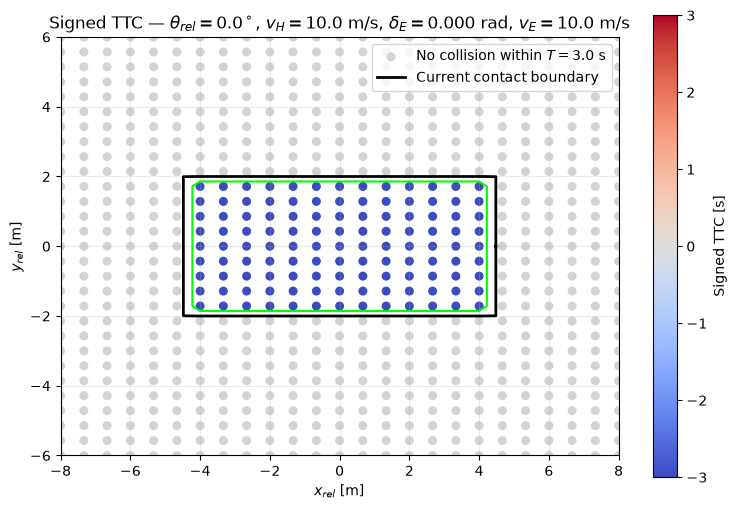

In [17]:
x_axis = np.asarray(grid.coordinate_vectors[0])
y_axis = np.asarray(grid.coordinate_vectors[1])
theta_axis = np.asarray(grid.coordinate_vectors[2])
v_H_axis = np.asarray(grid.coordinate_vectors[3])
delta_E_axis = np.asarray(grid.coordinate_vectors[4])
v_E_axis = np.asarray(grid.coordinate_vectors[5])

# Stato relativo da visualizzare
theta_target = np.deg2rad(0)
v_H_target = 10.0
delta_E_target = 0.0
v_E_target = 10.0

i_theta = int(np.argmin(np.abs(theta_axis - theta_target)))
i_v_H = int(np.argmin(np.abs(v_H_axis - v_H_target)))
i_delta_E = int(np.argmin(np.abs(delta_E_axis - delta_E_target)))
i_v_E = int(np.argmin(np.abs(v_E_axis - v_E_target)))

theta_plot = float(theta_axis[i_theta])
v_H_plot = float(v_H_axis[i_v_H])
delta_E_plot = float(delta_E_axis[i_delta_E])
v_E_plot = float(v_E_axis[i_v_E])

V0_slice = V0[
    :,
    :,
    i_theta,
    i_v_H,
    i_delta_E,
    i_v_E,
]

x_plot, y_plot = np.meshgrid(
    x_axis,
    y_axis,
    indexing="ij",
)

# Bordo geometrico del collision set
i_boundary = int(np.argmin(np.abs(boundary.theta - theta_plot)))
B_slice = boundary.points[i_boundary]
B_closed = np.vstack((B_slice, B_slice[0]))

# Scala simmetrica intorno allo zero
negative_limit = abs(float(np.min(V0_slice)))
positive_limit = min(
    float(np.max(V0_slice)),
    horizon,
)
value_limit = max(negative_limit, positive_limit, 1e-12)

norm = TwoSlopeNorm(
    vmin=-value_limit,
    vcenter=0.0,
    vmax=value_limit,
)

# I punti con valore 2T vengono mostrati in grigio:
# significano "nessuna collisione trovata entro T".
no_collision = np.isclose(
    V0_slice,
    result.no_collision_value,
)

fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    x_plot[~no_collision],
    y_plot[~no_collision],
    c=V0_slice[~no_collision],
    cmap="coolwarm",
    norm=norm,
    s=42,
    edgecolors="none",
)

ax.scatter(
    x_plot[no_collision],
    y_plot[no_collision],
    color="lightgray",
    s=42,
    edgecolors="none",
    label=rf"No collision within $T={horizon:.1f}$ s",
)

ax.plot(
    B_closed[:, 0],
    B_closed[:, 1],
    "k-",
    linewidth=2.0,
    label="Current contact boundary",
)

ax.contour(
    x_plot,
    y_plot,
    V0_slice,
    levels=[0.0],
    colors="lime",
    linewidths=1.5,
)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label(r"Signed TTC [s]")

ax.set_xlabel(r"$x_{rel}$ [m]")
ax.set_ylabel(r"$y_{rel}$ [m]")
ax.set_title(
    rf"Signed TTC — "
    rf"$\theta_{{rel}}={np.rad2deg(theta_plot):.1f}^\circ$, "
    rf"$v_H={v_H_plot:.1f}$ m/s, "
    rf"$\delta_E={delta_E_plot:.3f}$ rad, "
    rf"$v_E={v_E_plot:.1f}$ m/s"
)

ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.legend()

plt.show()

## 4. Grid for BRT

In [5]:
import hj_reachability as hj

from hj_reachability.systems.relative_vehicle_6d import RelativeVehicle6D

In [6]:
grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    domain=hj.sets.Box(
        lo=jnp.array([-8.0, -6.0, -np.pi, 0.0, -0.10, 0.0]),
        hi=jnp.array([ 8.0,  6.0,  np.pi, 20.0, 0.10, 20.0]),
    ),
    shape=(25, 29, 12, 3, 3, 3),
    periodic_dims=2,
)

print("Forma della griglia:", grid.shape)
print("Numero di stati:", int(np.prod(grid.shape)))

Forma della griglia: (25, 29, 12, 3, 3, 3)
Numero di stati: 234900


## 5. Terminal value function

In [7]:
V0 = metricTTC(
    grid=grid,
    dynamics=dynamics,
    horizon=horizon,
    dt=dt,
)

V0_BRT = V0.terminal_values

print("Forma di V0:", V0_BRT.shape)
print(
    "Intervallo di V0:",
    float(jnp.min(V0_BRT)),
    float(jnp.max(V0_BRT)),
)

Forma di V0: (25, 29, 12, 3, 3, 3)
Intervallo di V0: -3.0 6.0


## 6. Solver settings

In [8]:
solver_settings = hj.SolverSettings.with_accuracy(
    "low",
    hamiltonian_postprocessor=hj.solver.backwards_reachable_tube,
)

## 7. BRT calculation

In [12]:
time = 0.0
target_time = -2.0

BRT = hj.step(
    solver_settings,
    dynamics,
    grid,
    time,
    V0_BRT,
    target_time,
)

print("Forma di BRT:", BRT.shape)
print("Intervallo di BRT:", float(jnp.min(BRT)), float(np.max(BRT)))

100%|##########|  2.0000/2.0 [00:12<00:00,  6.10s/sim_s]

Forma di BRT: (25, 29, 12, 3, 3, 3)
Intervallo di BRT: -8.219179153442383 6.0


## 8. BRT slice

theta_rel plottato: 0.0 deg
v_H plottata: 10.0 m/s
delta_E plottato: 0.0 rad
v_E plottata: 10.0 m/s


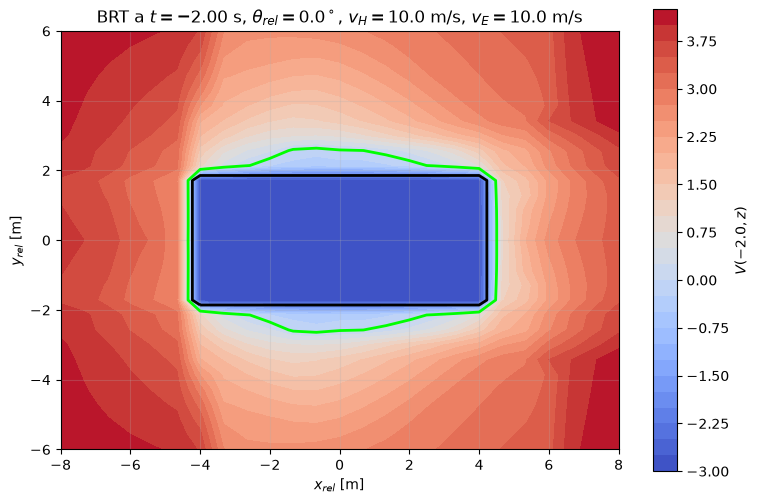

In [14]:
x_axis = np.asarray(grid.coordinate_vectors[0])
y_axis = np.asarray(grid.coordinate_vectors[1])
theta_axis = np.asarray(grid.coordinate_vectors[2])
v_H_axis = np.asarray(grid.coordinate_vectors[3])
delta_E_axis = np.asarray(grid.coordinate_vectors[4])
v_E_axis = np.asarray(grid.coordinate_vectors[5])

theta_target = np.deg2rad(0)
v_H_target = 10.0
delta_E_target = 0.0
v_E_target = 10.0

i_theta = int(np.argmin(np.abs(theta_axis - theta_target)))
i_v_H = int(np.argmin(np.abs(v_H_axis - v_H_target)))
i_delta_E = int(np.argmin(np.abs(delta_E_axis - delta_E_target)))
i_v_E = int(np.argmin(np.abs(v_E_axis - v_E_target)))

V0_plot = np.asarray(
    V0_BRT[:, :, i_theta, i_v_H, i_delta_E, i_v_E]
)

BRT_plot = np.asarray(
    BRT[:, :, i_theta, i_v_H, i_delta_E, i_v_E]
)

print("theta_rel plottato:", np.rad2deg(theta_axis[i_theta]), "deg")
print("v_H plottata:", v_H_axis[i_v_H], "m/s")
print("delta_E plottato:", delta_E_axis[i_delta_E], "rad")
print("v_E plottata:", v_E_axis[i_v_E], "m/s")

fig, ax = plt.subplots(figsize=(9, 6))

contour = ax.contourf(
    x_axis,
    y_axis,
    BRT_plot.T,
    levels=30,
    cmap="coolwarm",
)

fig.colorbar(
    contour,
    ax=ax,
    label=rf"$V({target_time},z)$",
)

# Bordo del terminal set originale: V0 = 0
ax.contour(
    x_axis,
    y_axis,
    V0_plot.T,
    levels=[0.0],
    colors="black",
    linewidths=2.0,
)

# Bordo del BRT propagato: V(-T,z) = 0
ax.contour(
    x_axis,
    y_axis,
    BRT_plot.T,
    levels=[0.0],
    colors="lime",
    linewidths=2.0,
)

ax.set_xlabel(r"$x_{rel}$ [m]")
ax.set_ylabel(r"$y_{rel}$ [m]")
ax.set_title(
    rf"BRT a $t={target_time:.2f}$ s, "
    rf"$\theta_{{rel}}={np.rad2deg(theta_axis[i_theta]):.1f}^\circ$, "
    rf"$v_H={v_H_axis[i_v_H]:.1f}$ m/s, "
    rf"$v_E={v_E_axis[i_v_E]:.1f}$ m/s"
)

ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)

plt.show()

# 9. 3D BRT plot
For fixed:
- $v_H$
- $\delta_E$
- $v_E$

In [11]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

v_H_target = 10.0
delta_E_target = 0.0
v_E_target = 10.0

i_v_H = int(np.argmin(np.abs(v_H_axis - v_H_target)))
i_delta_E = int(np.argmin(np.abs(delta_E_axis - delta_E_target)))
i_v_E = int(np.argmin(np.abs(v_E_axis - v_E_target)))

BRT_3D = np.asarray(
    BRT[:, :, :, i_v_H, i_delta_E, i_v_E]
)

V0_3D = np.asarray(
    V0_BRT[:, :, :, i_v_H, i_delta_E, i_v_E]
)

print("Forma slice 3D:", BRT_3D.shape)

x_3D, y_3D, theta_3D = np.meshgrid(
    x_axis,
    y_axis,
    theta_axis,
    indexing="ij",
)

fig = go.Figure()

# Terminal set iniziale: V0 = 0
fig.add_trace(
    go.Isosurface(
        x=x_3D.ravel(),
        y=y_3D.ravel(),
        z=np.rad2deg(theta_3D.ravel()),
        value=V0_3D.ravel(),
        isomin=0.0,
        isomax=0.0,
        surface_count=1,
        colorscale=[[0.0, "black"], [1.0, "black"]],
        opacity=0.45,
        caps=dict(x_show=False, y_show=False, z_show=False),
        name="Terminal set",
        showscale=False,
    )
)

# BRT propagato: V(t,z) = 0
fig.add_trace(
    go.Isosurface(
        x=x_3D.ravel(),
        y=y_3D.ravel(),
        z=np.rad2deg(theta_3D.ravel()),
        value=BRT_3D.ravel(),
        isomin=0.0,
        isomax=0.0,
        surface_count=1,
        colorscale=[[0.0, "lime"], [1.0, "lime"]],
        opacity=0.55,
        caps=dict(x_show=False, y_show=False, z_show=False),
        name="BRT",
        showscale=False,
    )
)

fig.update_layout(
    title=(
        f"BRT a t = {target_time:.2f} s — "
        f"v_H = {v_H_axis[i_v_H]:.1f} m/s, "
        f"delta_E = {delta_E_axis[i_delta_E]:.3f} rad, "
        f"v_E = {v_E_axis[i_v_E]:.1f} m/s"
    ),

    scene=dict(
        xaxis=dict(
            title="x_rel [m]",
            backgroundcolor="white",
            gridcolor="lightgray",
        ),
        yaxis=dict(
            title="y_rel [m]",
            backgroundcolor="white",
            gridcolor="lightgray",
        ),
        zaxis=dict(
            title="theta_rel [deg]",
            tickmode="array",
            tickvals=[-180, -90, 0, 90, 180],
            backgroundcolor="white",
            gridcolor="lightgray",
        ),

        # Proporzioni grafiche indipendenti dalle unità fisiche
        aspectmode="manual",
        aspectratio=dict(
            x=1.4,
            y=1.0,
            z=1.2,
        ),

        camera=dict(
            eye=dict(x=1.6, y=1.6, z=1.15),
            up=dict(x=0, y=0, z=1),
        ),
    ),

    width=1000,
    height=750,
    margin=dict(l=20, r=20, b=20, t=70),
)

fig.show()

Forma slice 3D: (25, 29, 12)
